# Assignment 9 - Class Work
## Topic: Decision Tree

### Question 1
Load the Iris dataset from sklearn.datasets. Display the first 10 rows and identify the input features and target variable.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display first 10 rows
print(df.head(10).to_string())

# Identify features and target
print("\nFeatures:", list(iris.feature_names))
print("Target variable: target (0=setosa, 1=versicolor, 2=virginica)")

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target species
0                5.1               3.5                1.4               0.2       0  setosa
1                4.9               3.0                1.4               0.2       0  setosa
2                4.7               3.2                1.3               0.2       0  setosa
3                4.6               3.1                1.5               0.2       0  setosa
4                5.0               3.6                1.4               0.2       0  setosa
5                5.4               3.9                1.7               0.4       0  setosa
6                4.6               3.4                1.4               0.3       0  setosa
7                5.0               3.4                1.5               0.2       0  setosa
8                4.4               2.9                1.4               0.2       0  setosa
9                4.9               3.1                1.5               0.1     

### Question 2
Create scatter plots for at least two pairs of features (e.g., Petal Length vs Petal Width, Sepal Length vs Sepal Width) to visualize class separability. Use different colors for each species.

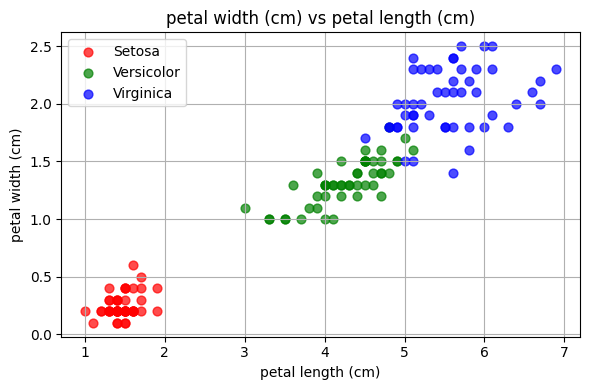

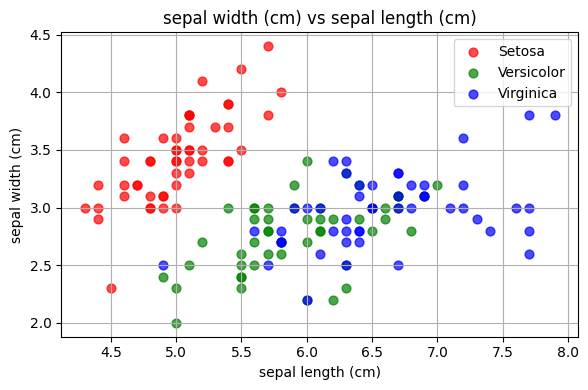

In [2]:
import matplotlib.pyplot as plt

# Define colors and labels for each class
colors = {0: 'red', 1: 'green', 2: 'blue'}
labels = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

# Feature pairs to visualize
pairs = [
    ('petal length (cm)', 'petal width (cm)'),
    ('sepal length (cm)', 'sepal width (cm)'),
]

for (feat_x, feat_y) in pairs:
    plt.figure(figsize=(6, 4))
    for cls in [0, 1, 2]:
        subset = df[df['target'] == cls]
        plt.scatter(subset[feat_x], subset[feat_y], c=colors[cls],
                    label=labels[cls], alpha=0.7, s=40)
    plt.xlabel(feat_x)
    plt.ylabel(feat_y)
    plt.title(f'{feat_y} vs {feat_x}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Question 3
Build a Decision Tree classifier using sklearn.tree.DecisionTreeClassifier. Train the model and print the predicted classes for the test set.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

print("----- Decision Tree Classifier -----")

# Prepare features and target
X = iris.data
y = iris.target

# Split into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nTraining set size:", len(X_train))
print("Testing set size:", len(X_test))

# Build Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

print("\nDecision Tree Model Trained Successfully.")

# Predict classes for the test set
y_pred = dt.predict(X_test)
print("\nPredicted classes for the test set:")
print(y_pred)

----- Decision Tree Classifier -----

Training set size: 105
Testing set size: 45

Decision Tree Model Trained Successfully.

Predicted classes for the test set:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


### Question 4
Evaluate the Decision Tree classifier using accuracy, confusion matrix, and classification report.

----- Model Evaluation -----

Accuracy: 1.0

Classification Report (Precision, Recall, F1-score per class):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

----- Confusion Matrix -----

 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


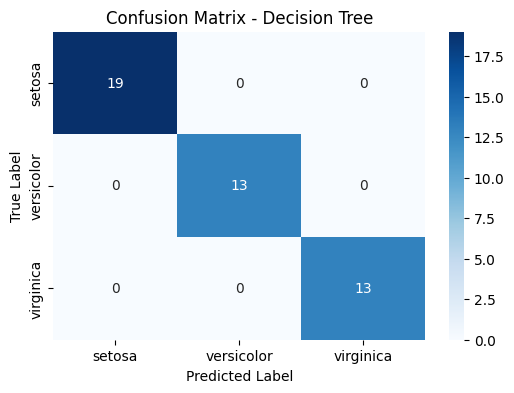

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("----- Model Evaluation -----")

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

# Classification Report
print("\nClassification Report (Precision, Recall, F1-score per class):")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
print("----- Confusion Matrix -----")
cm = confusion_matrix(y_test, y_pred)
print("\n", cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### Question 5
Visualize the trained decision tree using plot_tree and export it as text.

----- Decision Tree Visualization -----


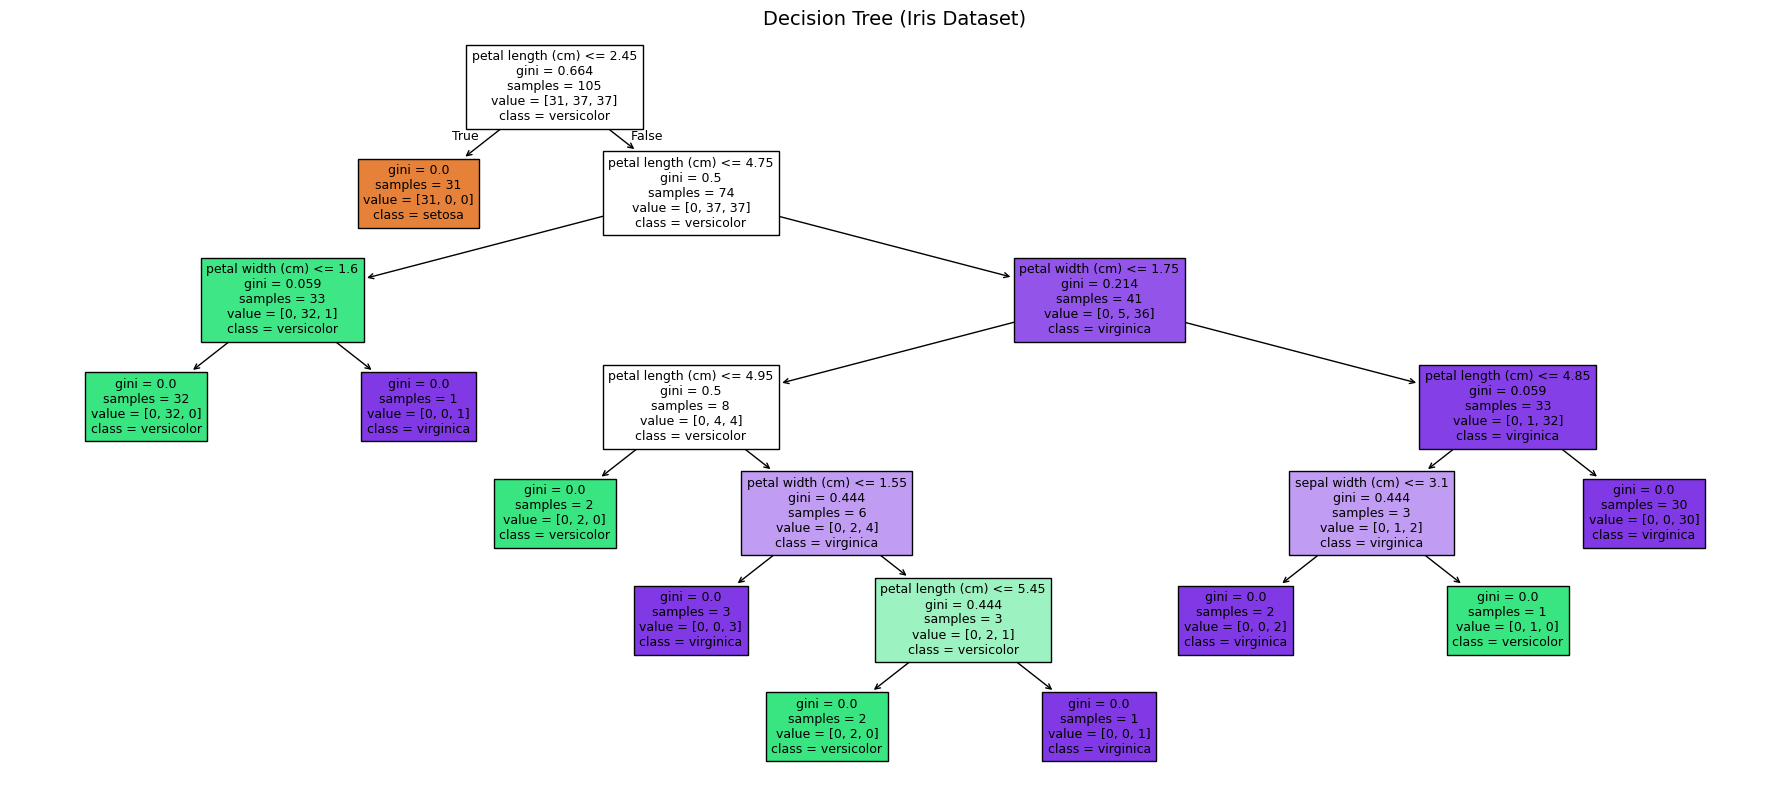


Text representation of the Decision Tree:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   | 

In [5]:
from sklearn.tree import plot_tree, export_text

print("----- Decision Tree Visualization -----")

# Plot the decision tree
plt.figure(figsize=(18, 8))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, fontsize=9)
plt.title('Decision Tree (Iris Dataset)', fontsize=14)
plt.tight_layout()
plt.show()

# Export tree as text
print("\nText representation of the Decision Tree:")
tree_text = export_text(dt, feature_names=list(iris.feature_names))
print(tree_text)

### Question 6
Predict the species of a new Iris flower with the following features: Sepal Length = 5.4, Sepal Width = 3.0, Petal Length = 4.5, Petal Width = 1.5

In [6]:
print("----- New Flower Prediction -----")

# New flower features
new_sample = [[5.4, 3.0, 4.5, 1.5]]

print("\nInput Features:")
print("  Sepal Length = 5.4 cm")
print("  Sepal Width  = 3.0 cm")
print("  Petal Length = 4.5 cm")
print("  Petal Width  = 1.5 cm")

# Predict class
pred_class = dt.predict(new_sample)[0]
pred_prob = dt.predict_proba(new_sample)[0]

species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
print(f"\nPredicted Class: {pred_class} ({species_map[pred_class]})")

print("\nPrediction Probabilities:")
for i, name in enumerate(iris.target_names):
    print(f"  {name.capitalize()}: {pred_prob[i]:.2f}")

print(f"\nThe new Iris flower is predicted to be: {species_map[pred_class].upper()}")

----- New Flower Prediction -----

Input Features:
  Sepal Length = 5.4 cm
  Sepal Width  = 3.0 cm
  Petal Length = 4.5 cm
  Petal Width  = 1.5 cm

Predicted Class: 1 (versicolor)

Prediction Probabilities:
  Setosa: 0.00
  Versicolor: 1.00
  Virginica: 0.00

The new Iris flower is predicted to be: VERSICOLOR
